In [ ]:
%load_ext autoreload
%autoreload 2

# 1. Raw Data Exploration

Explore the M5 dataset structure and statistics.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))

import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent))
from src.data.loader import load_calendar, load_prices, load_sales

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Load Raw Data

In [2]:
raw_path = '../data/raw'

print("Loading raw M5 data...")
calendar = load_calendar(raw_path)
prices = load_prices(raw_path)
sales = load_sales(raw_path)

print(f"Calendar shape: {calendar.shape}")
print(f"Prices shape: {prices.shape}")
print(f"Sales shape: {sales.shape}")

Loading raw M5 data...
Calendar shape: (1969, 14)
Prices shape: (6841121, 4)
Sales shape: (30490, 1947)


## Explore Calendar Data

In [3]:
print("Calendar Data:")
print(calendar.head())
print(f"\nColumns: {calendar.columns.tolist()}")
print(f"\nDate range: {calendar['date'].min()} to {calendar['date'].max()}")
print(f"\nEvent types:")
print(calendar['event_type_1'].value_counts().head(10))
print(calendar['event_type_2'].value_counts().head(10))

Calendar Data:
         date  wm_yr_wk    weekday  wday  month  year    d event_name_1  \
0  2011-01-29     11101   Saturday     1      1  2011  d_1          NaN   
1  2011-01-30     11101     Sunday     2      1  2011  d_2          NaN   
2  2011-01-31     11101     Monday     3      1  2011  d_3          NaN   
3  2011-02-01     11101    Tuesday     4      2  2011  d_4          NaN   
4  2011-02-02     11101  Wednesday     5      2  2011  d_5          NaN   

  event_type_1 event_name_2 event_type_2  snap_CA  snap_TX  snap_WI  
0          NaN          NaN          NaN        0        0        0  
1          NaN          NaN          NaN        0        0        0  
2          NaN          NaN          NaN        0        0        0  
3          NaN          NaN          NaN        1        1        0  
4          NaN          NaN          NaN        1        0        1  

Columns: ['date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year', 'd', 'event_name_1', 'event_type_1', 'event_nam

## Explore Prices Data

In [4]:
print("Prices Data:")
print(prices.head())
print(f"\nStores: {prices['store_id'].nunique()}")
print(f"Items: {prices['item_id'].nunique()}")
print(f"\nPrice statistics:")
print(prices['sell_price'].describe())

Prices Data:
  store_id        item_id  wm_yr_wk  sell_price
0     CA_1  HOBBIES_1_001     11325        9.58
1     CA_1  HOBBIES_1_001     11326        9.58
2     CA_1  HOBBIES_1_001     11327        8.26
3     CA_1  HOBBIES_1_001     11328        8.26
4     CA_1  HOBBIES_1_001     11329        8.26

Stores: 10
Items: 3049

Price statistics:
count    6.841121e+06
mean     4.410952e+00
std      3.408814e+00
min      1.000000e-02
25%      2.180000e+00
50%      3.470000e+00
75%      5.840000e+00
max      1.073200e+02
Name: sell_price, dtype: float64


## Explore Sales Data

In [5]:
print("Sales Data (first 5 rows, first 15 columns):")
print(sales.iloc[:5, :15])
print(f"\nStores: {sales['store_id'].nunique()}")
print(f"Items: {sales['item_id'].nunique()}")
print(f"Categories: {sales['cat_id'].nunique()}")
print(f"Departments: {sales['dept_id'].nunique()}")


# Get sales columns (d_1, d_2, ...)
sales_cols = [col for col in sales.columns if col.startswith('d_')]
print(f"\nNumber of time periods: {len(sales_cols)}")

print(f"\nNumber of time series: {sales['store_id'].nunique()*sales['item_id'].nunique()}")


Sales Data (first 5 rows, first 15 columns):
                              id        item_id    dept_id   cat_id store_id  \
0  HOBBIES_1_001_CA_1_evaluation  HOBBIES_1_001  HOBBIES_1  HOBBIES     CA_1   
1  HOBBIES_1_002_CA_1_evaluation  HOBBIES_1_002  HOBBIES_1  HOBBIES     CA_1   
2  HOBBIES_1_003_CA_1_evaluation  HOBBIES_1_003  HOBBIES_1  HOBBIES     CA_1   
3  HOBBIES_1_004_CA_1_evaluation  HOBBIES_1_004  HOBBIES_1  HOBBIES     CA_1   
4  HOBBIES_1_005_CA_1_evaluation  HOBBIES_1_005  HOBBIES_1  HOBBIES     CA_1   

  state_id  d_1  d_2  d_3  d_4  d_5  d_6  d_7  d_8  d_9  
0       CA    0    0    0    0    0    0    0    0    0  
1       CA    0    0    0    0    0    0    0    0    0  
2       CA    0    0    0    0    0    0    0    0    0  
3       CA    0    0    0    0    0    0    0    0    0  
4       CA    0    0    0    0    0    0    0    0    0  

Stores: 10
Items: 3049
Categories: 3
Departments: 7

Number of time periods: 1941

Number of time series: 30490


## Sales Distribution

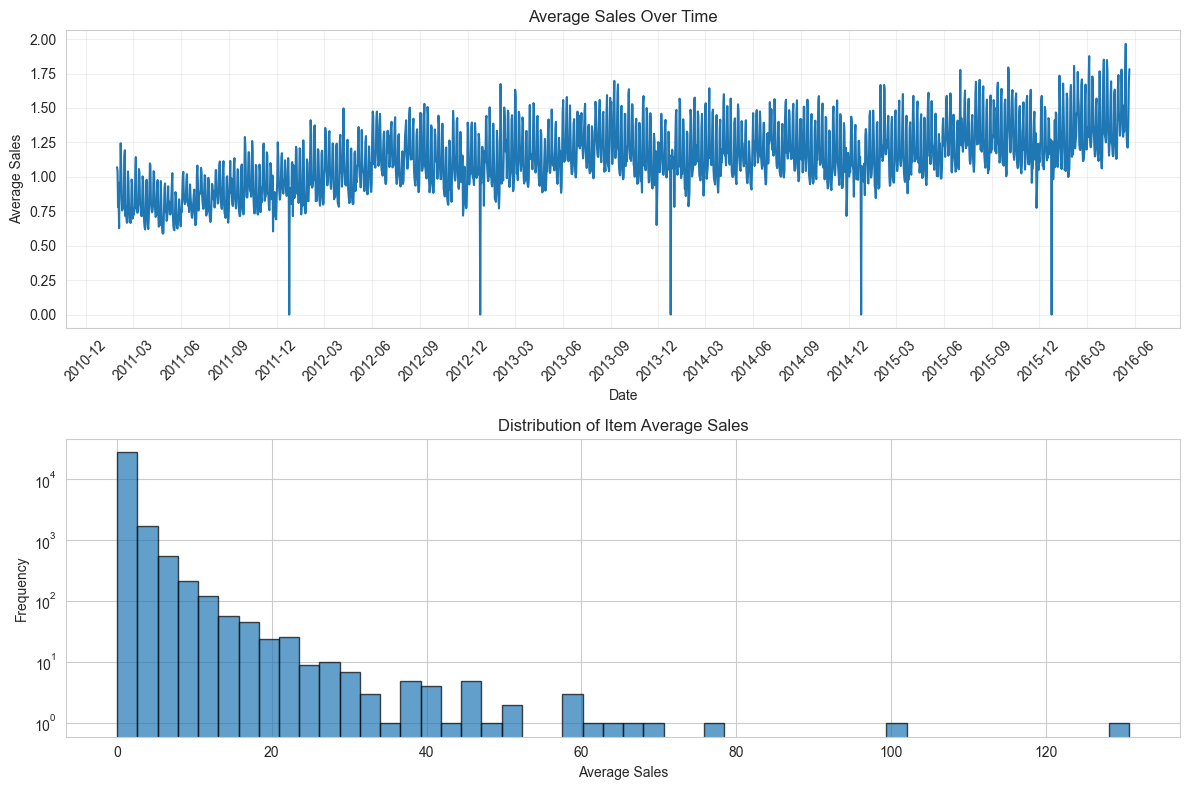

Average daily sales: 1.13
Average item sales: 1.13


In [6]:
import pandas as pd
import matplotlib.dates as mdates

# Calculate average sales per day
sales_cols = [col for col in sales.columns if col.startswith('d_')]
daily_sales = sales[sales_cols].mean()

# Map d_ columns to real dates from the calendar table
calendar_dates = calendar.set_index('d')['date']
daily_sales.index = pd.to_datetime(calendar_dates.reindex(sales_cols).values)

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Time series of average sales
axes[0].plot(daily_sales.index, daily_sales.values)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Average Sales')
axes[0].set_title('Average Sales Over Time')
axes[0].grid(True, alpha=0.3)
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[0].tick_params(axis='x', rotation=45)

# Distribution of average item sales
item_avg_sales = sales[sales_cols].mean(axis=1)
axes[1].hist(item_avg_sales, bins=50, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Average Sales')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Item Average Sales')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

print(f"Average daily sales: {daily_sales.mean():.2f}")
print(f"Average item sales: {item_avg_sales.mean():.2f}")

## Store Analysis

Average Sales by Store:
store_id
CA_3    1.920130
CA_1    1.323438
TX_2    1.238511
WI_2    1.131778
WI_3    1.105515
TX_3    1.048636
CA_2    0.983151
TX_1    0.961933
WI_1    0.889052
CA_4    0.706735
dtype: float64


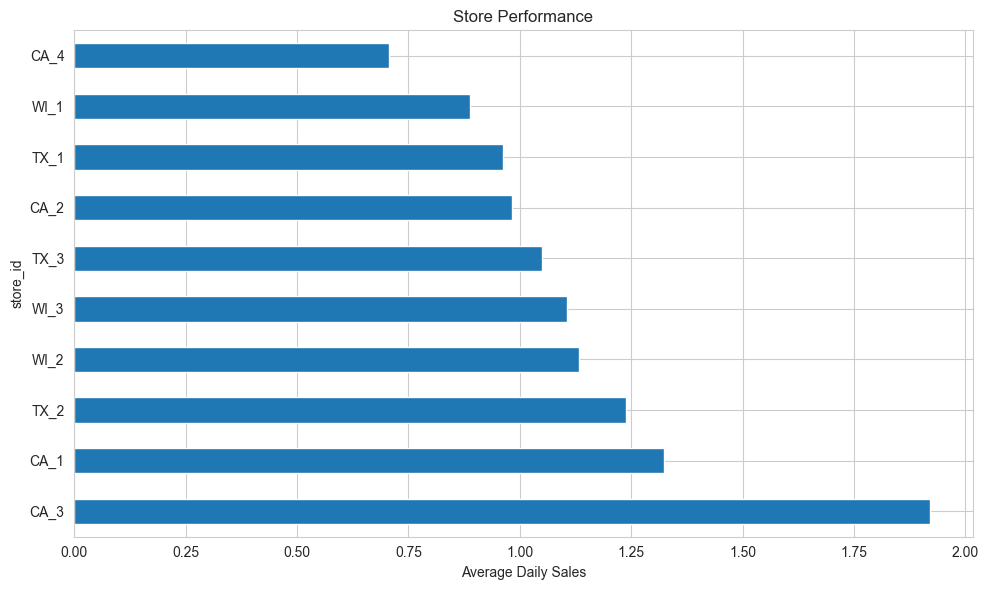

In [7]:
store_stats = sales.groupby('store_id')[sales_cols].mean().mean(axis=1).sort_values(ascending=False)

print("Average Sales by Store:")
print(store_stats)

plt.figure(figsize=(10, 6))
store_stats.plot(kind='barh')
plt.xlabel('Average Daily Sales')
plt.title('Store Performance')
plt.tight_layout()
plt.show()

## Summary Statistics

In [8]:
print("\n=== DATASET SUMMARY ===")
print(f"Time periods: {len(sales_cols)} days")
print(f"Stores: {sales['store_id'].nunique()}")
print(f"Categories: {sales['cat_id'].nunique()}")
print(f"Items: {sales['item_id'].nunique()}")
print(f"\nTotal items (store-item combinations): {len(sales)}")
print(f"\nCalendar features:")
print(f"  - Dates: {calendar['date'].nunique()}")
print(f"  - Events tracked: {calendar['event_type_1'].nunique()} unique event types")


=== DATASET SUMMARY ===
Time periods: 1941 days
Stores: 10
Categories: 3
Items: 3049

Total items (store-item combinations): 30490

Calendar features:
  - Dates: 1969
  - Events tracked: 4 unique event types
